<h1>A biblioteca <code>transformers</code> da Hugging Face</h1>
<i>Introdução à infraestrutura que usaremos para carregar e inspecionar LLMs</i>

---

**Material de apoio da disciplina Tópicos Especiais em Inteligência Artificial (IFPE, Campus Paulista)**

Este notebook é um **pré-requisito** para o notebook "Capítulo 3 - Olhando por Dentro dos LLMs", que carrega o modelo Phi-3-mini diretamente com `AutoTokenizer` e `AutoModelForCausalLM`. Antes de mergulhar na arquitetura interna do Transformer, é importante entender o que é essa biblioteca, como ela organiza os modelos, e como carregá-los e inspecioná-los de forma direta.

**Escopo deste notebook:** o que é a Hugging Face, o que é a biblioteca `transformers`, como o Hugging Face Hub distribui modelos, o que são as classes `Auto*`, como carregar um tokenizador e um modelo manualmente, e como interpretar os principais parâmetros de `from_pretrained`.

**Fora do escopo (propositalmente):** a classe `transformers.pipeline`. Ela será apresentada em um notebook futuro, dedicado especificamente a ela, pois é apenas uma camada de conveniência construída sobre o que veremos aqui (tokenizador + modelo + `generate`).

# O que é a Hugging Face

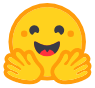


A Hugging Face é uma empresa e comunidade que se tornou o principal ponto de encontro do ecossistema de Processamento de Linguagem Natural (PLN) e, mais recentemente, de LLMs em geral. Ela mantém, entre outros projetos:

- **Hugging Face Hub**: um repositório público (com opção de repositórios privados) de modelos pré-treinados, conjuntos de dados e demonstrações interativas (Spaces). No momento em que o livro *Hands-On Large Language Models* foi escrito, o Hub já hospedava mais de 60 mil modelos apenas para classificação de texto, e mais de 8 mil modelos geradores de embeddings (ALAMMAR; GROOTENDORST, 2024, p. 115). Hoje esse número é ainda maior.
- **`transformers`**: a biblioteca Python que permite carregar, treinar e usar esses modelos com uma interface unificada. É o foco deste notebook.
- **`datasets`**: biblioteca para carregar e manipular conjuntos de dados de forma eficiente (incluindo datasets grandes demais para caber na memória).
- **`tokenizers`**: implementação de baixo nível (em Rust, com bindings em Python) dos algoritmos de tokenização usados pelos modelos (BPE, WordPiece, Unigram), já explorados na aula sobre tokens e embeddings.
- **`accelerate`**: biblioteca que facilita a execução de modelos em múltiplas GPUs, CPUs ou em precisão reduzida, sem que o código de treinamento/inferência precise mudar.

Neste notebook, o foco é exclusivamente a biblioteca `transformers` e o Hub, que juntos formam a base sobre a qual carregaremos e inspecionaremos o Phi-3-mini no notebook seguinte.

# O que é a biblioteca `transformers`

A biblioteca `transformers` oferece uma **interface unificada** para carregar centenas de arquiteturas de modelos diferentes (BERT, GPT, Llama, Phi, Mistral, T5, entre muitas outras) usando praticamente o mesmo padrão de código, independentemente da arquitetura interna de cada uma. Ela também abstrai o framework de deep learning por trás: os mesmos modelos podem, em muitos casos, ser executados com PyTorch, TensorFlow ou JAX.

Isso resolve um problema real: sem essa biblioteca, para usar um modelo específico seria necessário reimplementar (ou copiar) o código-fonte daquela arquitetura especificamente. Com `transformers`, o padrão de uso é sempre muito similar:

1. Baixar/carregar um **tokenizador** treinado junto com o modelo.
2. Baixar/carregar os **pesos do modelo**.
3. Tokenizar a entrada, passar pelo modelo, e interpretar a saída.

Já vimos uma parte desse padrão na aula sobre tokens e embeddings (o tokenizador). Neste notebook, vamos completar o quadro olhando para o carregamento do modelo em si e para as classes que a biblioteca oferece para isso.

Como o livro coloca, ao usar um LLM sempre carregamos, na prática, dois modelos: o modelo generativo propriamente dito, e o seu tokenizador correspondente. Ambos ficam hospedados juntos no mesmo repositório do Hugging Face Hub.

# O Hugging Face Hub e os identificadores de modelo

Cada modelo no Hub é identificado por uma string no formato `organização/nome-do-modelo`, por exemplo `microsoft/Phi-3-mini-4k-instruct` ou `bert-base-uncased`. Esse identificador é usado como argumento em praticamente todas as funções `from_pretrained` da biblioteca.

Um repositório de modelo no Hub tipicamente contém:

- **`config.json`**: metadados da arquitetura (tipo de modelo, número de camadas, dimensão dos embeddings, número de cabeças de atenção, tamanho do vocabulário, etc.). É esse arquivo que permite às classes `Auto*` (veremos a seguir) descobrir automaticamente qual implementação de modelo usar.
- **Arquivos do tokenizador**: `tokenizer.json`, `tokenizer_config.json`, `vocab.txt` ou `tokenizer.model`, dependendo do esquema de tokenização usado (BPE, WordPiece, SentencePiece).
- **Os pesos do modelo**: hoje preferencialmente no formato `.safetensors` (mais seguro e rápido de carregar do que o antigo `pytorch_model.bin`, pois não permite execução arbitrária de código ao ser desserializado). Modelos grandes ficam divididos em vários arquivos ("shards"), acompanhados de um índice (`model.safetensors.index.json`).
- **`README.md`** (o "model card"): documentação do modelo, incluindo licença, idiomas suportados, benchmarks e, muitas vezes, exemplos de uso.

Ao chamar `from_pretrained("microsoft/Phi-3-mini-4k-instruct")` pela primeira vez, a biblioteca baixa todos esses arquivos e os armazena em cache local (por padrão em `~/.cache/huggingface`). Chamadas seguintes reutilizam o cache, sem precisar baixar novamente.

https://huggingface.co/microsoft/Phi-3.5-mini-instruct

# As classes `Auto*`: descoberta automática de arquitetura

Em vez de o desenvolvedor precisar saber de antemão que o Phi-3 usa a classe `Phi3ForCausalLM`, ou que o BERT usa `BertModel`, a biblioteca oferece **classes genéricas** que leem o `config.json` do repositório e escolhem automaticamente a implementação correta. Essas são as classes `Auto*`:

- **`AutoConfig`**: carrega apenas os metadados da arquitetura (`config.json`), sem baixar os pesos. Útil para inspecionar rapidamente as características de um modelo antes de decidir se vale a pena baixá-lo por completo.
- **`AutoTokenizer`**: carrega o tokenizador correto (BPE, WordPiece, SentencePiece, etc.) para aquele modelo especificamente.
- **`AutoModel`**: carrega a arquitetura "crua" do modelo (a pilha de blocos Transformer), sem nenhuma cabeça de tarefa específica acoplada. Retorna diretamente os vetores de saída (hidden states) do modelo.
- **Classes `AutoModelFor<Tarefa>`**: carregam o modelo já com uma "cabeça" (camada final) apropriada para uma tarefa específica. As mais relevantes para esta disciplina:
  - `AutoModelForCausalLM`: modelos generativos autoregressivos (decoder-only), como o Phi-3, Llama, Mistral e a família GPT. É a classe que usaremos no próximo notebook.
  - `AutoModelForSequenceClassification`: modelos de classificação de texto (ex.: análise de sentimento), tipicamente construídos sobre arquiteturas encoder-only como BERT.
  - `AutoModelForTokenClassification`: modelos que classificam cada token individualmente (ex.: reconhecimento de entidades nomeadas).
  - `AutoModelForMaskedLM`: modelos treinados com modelagem de linguagem mascarada (a tarefa de pré-treinamento do BERT).

O livro *Hands-On Large Language Models* organiza essa distinção em dois grandes grupos: **modelos de representação** (encoder-only, como BERT, focados em gerar embeddings e não em gerar texto) e **modelos generativos** (decoder-only, como GPT e Phi, focados em completar/gerar texto). Essa distinção também aparece na escolha da classe `Auto*` correta: modelos de representação costumam ser carregados com `AutoModel` ou `AutoModelForSequenceClassification`; modelos generativos, com `AutoModelForCausalLM`.

# Na prática: inspecionando um modelo antes de baixá-lo por completo

Antes de baixar os pesos completos de um modelo (que podem ter vários gigabytes), é uma boa prática inspecionar sua configuração com `AutoConfig`. Isso baixa apenas o `config.json` (poucos kilobytes) e permite decidir se o modelo é compatível com o hardware disponível (número de parâmetros, tamanho do contexto, arquitetura).

Vamos inspecionar a configuração de dois modelos pequenos que usaremos como exemplo neste notebook: um modelo de representação (`distilbert-base-uncased`) e um modelo generativo (`distilgpt2`). Ambos são leves o suficiente para rodar em CPU, o que os torna adequados tanto para quem está usando Google Colab quanto para quem está em uma instância EC2 sem GPU.

In [ ]:
from transformers import AutoConfig

config_representacao = AutoConfig.from_pretrained("distilbert-base-uncased")
config_generativo = AutoConfig.from_pretrained("distilgpt2")

print("Modelo de representacao (distilbert-base-uncased)")
print("  tipo de modelo :", config_representacao.model_type)
print("  camadas        :", config_representacao.n_layers)
print("  dimensao oculta:", config_representacao.dim)
print("  vocabulario    :", config_representacao.vocab_size)
print()
print("Modelo generativo (distilgpt2)")
print("  tipo de modelo :", config_generativo.model_type)
print("  camadas        :", config_generativo.n_layer)
print("  dimensao oculta:", config_generativo.n_embd)
print("  vocabulario    :", config_generativo.vocab_size)
print("  contexto maximo:", config_generativo.n_ctx)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

Modelo de representacao (distilbert-base-uncased)
  tipo de modelo : distilbert
  camadas        : 6
  dimensao oculta: 768
  vocabulario    : 30522

Modelo generativo (distilgpt2)
  tipo de modelo : gpt2
  camadas        : 6
  dimensao oculta: 768
  vocabulario    : 50257
  contexto maximo: 1024


Note que os nomes exatos dos atributos de configuração variam de arquitetura para arquitetura (`dim` no DistilBERT, `n_embd` no GPT-2), pois cada família de modelos define seus próprios nomes de hiperparâmetros. Ainda assim, o padrão de uso da classe `AutoConfig` é sempre o mesmo, independentemente da arquitetura por trás. Essa é exatamente a vantagem das classes `Auto*`.

# Carregando um modelo de representação (encoder-only)

Vamos agora carregar de fato o tokenizador e o modelo `distilbert-base-uncased`, uma versão menor e mais rápida do BERT . Usamos `AutoModel` (sem sufixo de tarefa), que retorna diretamente os vetores de saída do modelo, sem nenhuma cabeça de tarefa acoplada.

Repare que, diferentemente do que faremos no próximo notebook, aqui **não** usamos `pipeline`: chamamos o tokenizador e o modelo diretamente. É exatamente esse par tokenizador + modelo que a `pipeline` encapsula por baixo dos panos, como veremos em um notebook futuro.

In [ ]:
from transformers import AutoTokenizer, AutoModel

tokenizer_repr = AutoTokenizer.from_pretrained("distilbert-base-uncased")
modelo_repr = AutoModel.from_pretrained("distilbert-base-uncased")

texto = "Transformers are the foundation of modern language models."
entrada = tokenizer_repr(texto, return_tensors="pt")

print("IDs de token:", entrada["input_ids"])
print("Tokens      :", tokenizer_repr.convert_ids_to_tokens(entrada["input_ids"][0]))

saida = modelo_repr(**entrada)

# last_hidden_state: um vetor por token de entrada
print("Formato de last_hidden_state:", saida.last_hidden_state.shape)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


IDs de token: tensor([[  101, 19081,  2024,  1996,  3192,  1997,  2715,  2653,  4275,  1012,
           102]])
Tokens      : ['[CLS]', 'transformers', 'are', 'the', 'foundation', 'of', 'modern', 'language', 'models', '.', '[SEP]']
Formato de last_hidden_state: torch.Size([1, 11, 768])


O formato de `last_hidden_state` segue o padrão `[lote, numero_de_tokens, dimensao_do_modelo]`. Diferentemente de um modelo generativo, aqui não existe uma `lm_head` prevendo o próximo token: o DistilBERT é bidirecional (atende tanto a tokens anteriores quanto posteriores) e produz um vetor contextualizado para **cada** token de entrada, não apenas para o último. Esses vetores são o ponto de partida para tarefas como classificação (geralmente usando o vetor do token especial `[CLS]`, o primeiro da sequência) ou geração de embeddings de frase, temas que serão aprofundados em aulas futuras sobre classificação e busca semântica.

**Fonte:** ALAMMAR; GROOTENDORST, 2024, cap. 1, seção "Representation Models: Encoder-Only Models", p. 17-19.

# Carregando um modelo generativo (decoder-only) sem usar `pipeline`

Agora repetimos o processo com um modelo generativo, o `distilgpt2` (uma versão destilada e menor do GPT-2). Para modelos generativos, usamos `AutoModelForCausalLM` em vez de `AutoModel`, pois queremos a "cabeça" de modelagem de linguagem (`lm_head`) acoplada, responsável por transformar a saída da pilha de blocos Transformer em uma distribuição de probabilidades sobre o vocabulário.

Assim como faremos no notebook seguinte com o Phi-3-mini, aqui tokenizamos manualmente o prompt, chamamos o modelo diretamente e usamos o método `generate` (que também não faz parte da `pipeline`, apenas é encapsulado por ela) para gerar texto token a token.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer_gen = AutoTokenizer.from_pretrained("distilgpt2")
modelo_gen = AutoModelForCausalLM.from_pretrained("distilgpt2")

prompt = "The history of artificial intelligence began"
entrada = tokenizer_gen(prompt, return_tensors="pt")

saida_gerada = modelo_gen.generate(
    **entrada,
    max_new_tokens=30,
    do_sample=False,
)

print(tokenizer_gen.decode(saida_gerada[0], skip_special_tokens=True))

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The history of artificial intelligence began in the late 1960s, when the company was developing a new artificial intelligence system called the DeepMind. The company developed a new artificial intelligence system called


Note que este é exatamente o mesmo padrão de código (tokenizador -> modelo -> `generate` -> decodificação) que será usado no notebook do Capítulo 3 para carregar o Phi-3-mini, apenas com um modelo bem menor para fins de demonstração rápida neste notebook introdutório. A diferença de escala entre o `distilgpt2` (82 milhões de parâmetros) e o Phi-3-mini (3,8 bilhões de parâmetros) é grande, mas a interface de uso da biblioteca `transformers` é idêntica nos dois casos: essa é justamente a vantagem central da biblioteca.

# Parâmetros importantes de `from_pretrained` para o nosso contexto

Ao carregar modelos maiores (como o Phi-3-mini no próximo notebook), alguns parâmetros de `from_pretrained` passam a ser relevantes, especialmente considerando que a disciplina roda em ambientes de recursos limitados (GPU gratuita do Colab ou instâncias EC2 sem GPU):

- **`device_map`**: controla em qual dispositivo o modelo será carregado. `device_map="cuda"` envia o modelo inteiro para a GPU; `device_map="auto"` distribui automaticamente as camadas do modelo entre os dispositivos disponíveis (útil quando o modelo é grande demais para uma única GPU); sem GPU disponível, basta omitir esse parâmetro (o modelo roda em CPU por padrão).
- **`torch_dtype`**: controla a precisão numérica dos pesos. `torch_dtype="auto"` deixa a biblioteca escolher a precisão recomendada pelo próprio modelo (tipicamente `bfloat16` ou `float16`), o que reduz pela metade o uso de memória em relação ao `float32` padrão, com perda de qualidade geralmente desprezível para inferência.
- **`trust_remote_code`**: alguns modelos (como o Phi-3) definem código Python customizado no próprio repositório do Hub para implementar sua arquitetura. Esse parâmetro precisa ser definido como `True` para que esse código seja executado. Como qualquer execução de código de terceiros, isso implica um risco de segurança; só deve ser habilitado para repositórios confiáveis (por exemplo, de organizações verificadas como `microsoft`, `google`, `meta-llama`).
- **`quantization_config`** (via `BitsAndBytesConfig`): permite carregar o modelo em precisão ainda menor (4 ou 8 bits), reduzindo drasticamente o uso de memória, ao custo de alguma perda de qualidade. É uma alternativa útil quando nem mesmo a GPU T4 gratuita do Colab (16 GB de VRAM) é suficiente para um modelo maior.

No próximo notebook, usaremos `device_map="cuda"` e `torch_dtype="auto"`. Se você estiver em uma instância EC2 sem GPU, lembre-se de omitir `device_map="cuda"` (ou trocar por um modelo consideravelmente menor, como sugerido naquele notebook).

# Resumo

- A **Hugging Face** mantém o **Hub**, um repositório de modelos pré-treinados, e a biblioteca **`transformers`**, que oferece uma interface unificada para carregar e usar esses modelos.
- Cada modelo no Hub é identificado por um par `organização/nome-do-modelo` e contém, tipicamente, um `config.json`, os arquivos do tokenizador e os pesos do modelo (hoje preferencialmente em `.safetensors`).
- As classes **`Auto*`** (`AutoConfig`, `AutoTokenizer`, `AutoModel`, `AutoModelForCausalLM`, entre outras) descobrem automaticamente, a partir do `config.json`, qual implementação de arquitetura usar, permitindo um padrão de código único para centenas de modelos diferentes.
- **Modelos de representação** (encoder-only, como o BERT/DistilBERT) são tipicamente carregados com `AutoModel` ou `AutoModelForSequenceClassification` e produzem vetores contextualizados para cada token de entrada.
- **Modelos generativos** (decoder-only, como GPT/Phi/Llama) são carregados com `AutoModelForCausalLM` e produzem, ao final, uma distribuição de probabilidades sobre o vocabulário para prever o próximo token, através do método `generate`.
- Parâmetros como `device_map`, `torch_dtype`, `trust_remote_code` e `quantization_config` controlam como o modelo é carregado na memória disponível, e serão especialmente relevantes ao carregar modelos maiores.
- O padrão tokenizador + modelo + `generate` que vimos aqui é exatamente o que a classe `pipeline` encapsula por conveniência, tema de um notebook futuro.

## Referências

* ALAMMAR, J.; GROOTENDORST, M. **Hands-On Large Language Models: Language Understanding and Generation**. Sebastopol: O'Reilly Media, 2024. Capítulo 1, "An Introduction to Large Language Models", e Capítulo 4, "Text Classification".

* Documentação oficial da biblioteca `transformers`: https://huggingface.co/docs/transformers

* Documentação das classes `Auto*`: https://huggingface.co/docs/transformers/model_doc/auto

* Hugging Face Hub: https://huggingface.co/models

* Documentação do formato `safetensors`: https://huggingface.co/docs/safetensors